In [9]:
import math
2+65

67

In [10]:
!python --version

Python 3.12.13


In [11]:
# Installation is handled in Cell 4 to avoid dependency conflicts.
print("Skip: use Cell 4 for Colab dependency setup.")

Skip: use Cell 4 for Colab dependency setup.


In [12]:
import sys
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import requests


def download_image_from_url(url: str, output_path: str = "plate.jpg") -> str:
    """Download image from URL and save locally."""
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0 Safari/537.36"
    }
    resp = requests.get(url, timeout=30, headers=headers)
    resp.raise_for_status()
    out = Path(output_path)
    out.write_bytes(resp.content)
    return str(out)


def _installed_version(pkg_name: str) -> str | None:
    try:
        return version(pkg_name)
    except PackageNotFoundError:
        return None


def _colab_runtime_needs_setup() -> bool:
    numpy_ver = _installed_version("numpy") or ""
    cv2_ver = _installed_version("opencv-python-headless") or ""
    paddle_ver = _installed_version("paddleocr") or ""
    return not (numpy_ver.startswith("1.26.") and cv2_ver.startswith("4.8.") and paddle_ver.startswith("2.7."))


if "google.colab" in sys.modules and _colab_runtime_needs_setup():
    print("Colab detected. Installing stable OCR dependencies...")
    get_ipython().run_line_magic("pip", "-q install -U pip setuptools wheel jedi")
    get_ipython().run_line_magic(
        "pip",
        "-q install -U --force-reinstall \"numpy>=1.26.4,<2\" \"scipy>=1.11.4,<1.12\" \"opencv-python-headless==4.8.1.78\" \"paddlepaddle==2.6.2\" \"paddleocr==2.7.3\" matplotlib requests",
    )
    print("Dependency install complete. Restart runtime, then run Cell 4 and Cell 5.")
elif "google.colab" in sys.modules:
    print("Colab runtime looks ready. Proceed to Cell 5.")
else:
    print("Not running in Colab. Skipping package installation.")

Colab runtime looks ready. Proceed to Cell 5.


Downloaded image: egypt_plate.jpg

OCR results:
1. text=بطن | score=1.000
2. text=رصم | score=0.996
3. text=٥٩٣ | score=0.814
4. text=5953 | score=0.694
5. text=GY | score=0.598


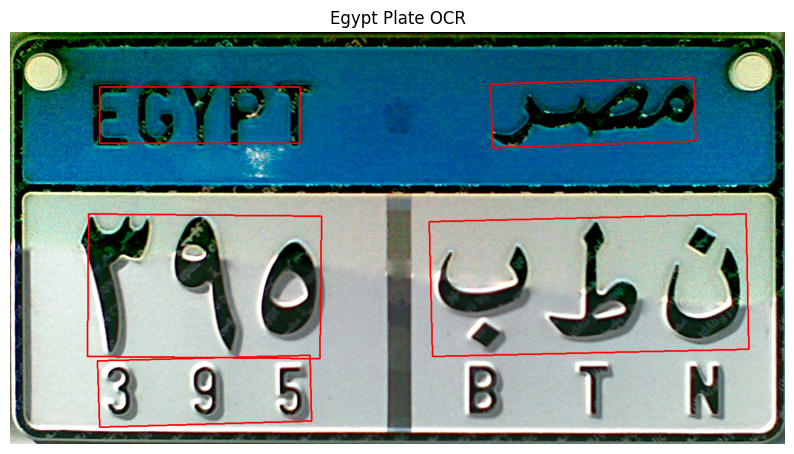


Best text: بطن


In [13]:
import json
import subprocess
import sys
import cv2
import matplotlib.pyplot as plt

# Base input: direct image URL (Egypt private plate sample).
image_url = "https://upload.wikimedia.org/wikipedia/commons/1/15/License_plate_Egypt_private.jpg"
image_path = download_image_from_url(image_url, "egypt_plate.jpg")
print("Downloaded image:", image_path)

# Run PaddleOCR in a clean subprocess to avoid notebook runtime conflicts.
ocr_code = r'''
import json
import os
from paddleocr import PaddleOCR

os.environ["PADDLE_PDX_EAGER_INIT"] = "0"
os.environ["PADDLE_PDX_ENABLE_MKLDNN_BYDEFAULT"] = "0"
os.environ["FLAGS_use_mkldnn"] = "0"

try:
    ocr = PaddleOCR(lang="ar", use_gpu=False)
except TypeError:
    ocr = PaddleOCR(
        lang="ar",
        device="cpu",
        text_detection_model_name="PP-OCRv5_mobile_det",
        text_recognition_model_name="arabic_PP-OCRv5_mobile_rec",
    )

result = ocr.ocr(r"'''+image_path+r'''")
lines = []
if result and result[0]:
    for item in result[0]:
        box, rec = item
        lines.append({
            "text": rec[0],
            "score": float(rec[1]),
            "box": box,
        })
print(json.dumps(lines, ensure_ascii=False))
'''

proc = subprocess.run(
    [sys.executable, "-c", ocr_code],
    capture_output=True,
    text=True,
    check=False,
)

predictions = []
if proc.returncode != 0:
    print("\nPaddleOCR failed. Error details:")
    print(proc.stderr)
else:
    stdout_lines = [ln for ln in proc.stdout.splitlines() if ln.strip()]
    if stdout_lines:
        predictions = json.loads(stdout_lines[-1])

predictions = sorted(predictions, key=lambda x: x["score"], reverse=True)
print("\nOCR results:")
if not predictions:
    print("No text detected.")
else:
    for i, p in enumerate(predictions, start=1):
        print(f"{i}. text={p['text']} | score={p['score']:.3f}")

img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError(f"Failed to read image: {image_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
for p in predictions:
    pts = [(int(x), int(y)) for x, y in p["box"]]
    for j in range(4):
        cv2.line(img_rgb, pts[j], pts[(j + 1) % 4], color=(255, 0, 0), thickness=2)

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Egypt Plate OCR")
plt.show()

if predictions:
    print("\nBest text:", predictions[0]["text"])

In [16]:
import random
import shutil
import subprocess
from pathlib import Path

# Real dataset source (public): https://github.com/ahmedramadan96/EALPR
repo_url = "https://github.com/ahmedramadan96/EALPR.git"
repo_dir = Path("EALPR")

if repo_dir.exists():
    print("EALPR repo already exists. Pulling latest...")
    subprocess.run(["git", "-C", str(repo_dir), "pull"], check=False)
else:
    print("Cloning EALPR dataset repo...")
    subprocess.run(["git", "clone", "--depth", "1", repo_url, str(repo_dir)], check=True)

# Known EALPR folders.
images_dir = repo_dir / "EALPR Vechicles dataset" / "Vehicles"
labels_dir = repo_dir / "EALPR Vechicles dataset" / "Vehicles Labeling"

# Fallback discovery if naming changes.
if not images_dir.exists() or not labels_dir.exists():
    dirs = [p for p in repo_dir.rglob("*") if p.is_dir()]
    for d in dirs:
        name = d.name.lower()
        if "vehicle" in name and "label" in name:
            labels_dir = d
        if name == "vehicles":
            images_dir = d

if not images_dir.exists() or not labels_dir.exists():
    raise FileNotFoundError("Could not find EALPR vehicle image/label folders")

print("Images folder:", images_dir)
print("Labels folder:", labels_dir)

img_exts = {".jpg", ".jpeg", ".png", ".bmp"}
all_images = [p for p in images_dir.iterdir() if p.suffix.lower() in img_exts]
all_images = sorted(all_images)

pairs = []
for img in all_images:
    lbl = labels_dir / f"{img.stem}.txt"
    if lbl.exists():
        pairs.append((img, lbl))

if len(pairs) < 50:
    raise RuntimeError(f"Too few image-label pairs found: {len(pairs)}")

print(f"Found {len(pairs)} image-label pairs")

# Build YOLO-ready train/val split.
out_root = Path("ealpr_yolo_dataset")
if out_root.exists():
    shutil.rmtree(out_root)

for rel in [
    "images/train", "images/val",
    "labels/train", "labels/val",
]:
    (out_root / rel).mkdir(parents=True, exist_ok=True)

random.seed(42)
random.shuffle(pairs)
split_idx = int(len(pairs) * 0.9)
train_pairs = pairs[:split_idx]
val_pairs = pairs[split_idx:]

def copy_pairs(subset_pairs, img_out_dir, lbl_out_dir):
    for img, lbl in subset_pairs:
        shutil.copy2(img, img_out_dir / img.name)
        shutil.copy2(lbl, lbl_out_dir / lbl.name)

copy_pairs(train_pairs, out_root / "images/train", out_root / "labels/train")
copy_pairs(val_pairs, out_root / "images/val", out_root / "labels/val")

# Create YOLO data.yaml
yaml_text = f'''path: {out_root.resolve().as_posix()}
train: images/train
val: images/val
names:
  0: license_plate
'''
(out_root / "data.yaml").write_text(yaml_text, encoding="utf-8")

print("Prepared dataset:", out_root.resolve())
print("Train:", len(train_pairs), "Val:", len(val_pairs))
print("YAML:", (out_root / "data.yaml").resolve())

EALPR repo already exists. Pulling latest...
Images folder: EALPR/EALPR Vechicles dataset/Vehicles
Labels folder: EALPR/EALPR Vechicles dataset/Vehicles Labeling
Found 2087 image-label pairs
Prepared dataset: /content/ealpr_yolo_dataset
Train: 1878 Val: 209
YAML: /content/ealpr_yolo_dataset/data.yaml


In [17]:
# Fine-tune a license plate detector on EALPR (Colab-friendly).
%pip -q install ultralytics

from pathlib import Path
from ultralytics import YOLO

data_yaml = Path("ealpr_yolo_dataset/data.yaml")
if not data_yaml.exists():
    raise FileNotFoundError("Run the dataset preparation cell first.")

model = YOLO("yolov8n.pt")

# Increase epochs for real training (e.g., 50-100 on Colab GPU).
results = model.train(
    data=str(data_yaml),
    epochs=10,
    imgsz=640,
    batch=16,
    project="runs/ealpr",
    name="yolov8n_plate",
    pretrained=True,
    device=0 if __import__("torch").cuda.is_available() else "cpu",
)

print("Training finished.")
print("Best model:", Path(results.save_dir) / "weights" / "best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=ealpr_yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz

In [ ]:
from pathlib import Path
import zipfile
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1) Pick best trained weights (search common Ultralytics output folders)
search_roots = [Path("runs/ealpr"), Path("runs/detect"), Path("/content/runs"), Path("runs")]
candidates = []
for root in search_roots:
    if root.exists():
        candidates.extend(root.glob("**/weights/best.pt"))
candidates = sorted(set(candidates))

if not candidates:
    raise FileNotFoundError(
        "No best.pt found. Run the training cell in this same runtime, then re-run this cell."
    )

best_weights = candidates[-1]
print("Using weights:", best_weights)

# 2) Pick input image (reuses earlier image_path if available)
test_image = Path(image_path) if "image_path" in globals() else Path("egypt_plate.jpg")
if not test_image.exists():
    raise FileNotFoundError(f"Test image not found: {test_image}")
print("Using image:", test_image)

# 3) Run detection + save visual result
det_model = YOLO(str(best_weights))
pred = det_model.predict(source=str(test_image), conf=0.25, save=False, verbose=False)
vis_bgr = pred[0].plot()  # annotated BGR image
vis_rgb = cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB)

artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)
vis_path = artifact_dir / "egypt_plate_detected.jpg"
cv2.imwrite(str(vis_path), vis_bgr)

plt.figure(figsize=(10, 6))
plt.imshow(vis_rgb)
plt.axis("off")
plt.title("Fine-tuned Plate Detector Result")
plt.show()

# 4) Pack downloadable artifacts
zip_path = artifact_dir / "ealpr_results_bundle.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(best_weights, arcname="weights/best.pt")
    zf.write(vis_path, arcname="predictions/egypt_plate_detected.jpg")
print("Saved annotated image:", vis_path)
print("Saved bundle zip:", zip_path)

# 5) Optional one-click download in Colab runtime
try:
    from google.colab import files
    files.download(str(zip_path))
except Exception:
    print("Not in Colab notebook UI. Download manually from Files panel:")
    print(f" - {vis_path}")
    print(f" - {zip_path}")

FileNotFoundError: No best.pt found under runs/ealpr. Run training cell first.